<a href="https://colab.research.google.com/github/nomanahmed21/AutoTuneAI/blob/main/Automated_Hyper_parameter_tuning_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/python_libs')

In [ ]:
from agent import BayesianAutoTuneAgent

In [ ]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import GradientBoostingRegressor

# dataset
X, y = make_regression(n_samples=300, n_features=10, noise=20, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
def train_fn(config):
    model = GradientBoostingRegressor(
        n_estimators=config["n_estimators"],
        learning_rate=config["learning_rate"],
        max_depth=config["max_depth"],
        min_samples_split=config["min_samples_split"],
        min_samples_leaf=config["min_samples_leaf"],
        subsample=config["subsample"],
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return r2_score(y_test, preds)

In [ ]:
search_space = {
    "n_estimators": [50, 300],        # int
    "learning_rate": (0.01, 0.3),     # float
    "max_depth": [2, 8],              # int
    "min_samples_split": [2, 10],     # int
    "min_samples_leaf": [1, 5],       # int
    "subsample": (0.5, 1.0)           # float
}

In [ ]:
agent = BayesianAutoTuneAgent(search_space, train_fn=train_fn, warmup_samples=20, max_workers=8)

🚀 Running parallel warmup with 20 samples...
✅ Warmup completed with 20 samples


In [ ]:
best = agent.run(
    train_fn=train_fn,
    trials=50,
    patience=15,
    parallel_eval=1
)

🎯 Exploiting (σ=0.054, μ=0.891, EI=0.0147)
Trial 1/50: score=0.9072 | best=0.9072
🎯 Exploiting (σ=0.068, μ=0.827, EI=0.0039)
Trial 2/50: score=0.8207 | best=0.9072
🎯 Exploiting (σ=0.067, μ=0.827, EI=0.0036)
Trial 3/50: score=0.8311 | best=0.9072
🎯 Exploiting (σ=0.065, μ=0.827, EI=0.0033)
Trial 4/50: score=0.8450 | best=0.9072
🎯 Exploiting (σ=0.064, μ=0.828, EI=0.0032)
Trial 5/50: score=0.8369 | best=0.9072
🎯 Exploiting (σ=0.063, μ=0.828, EI=0.0030)
Trial 6/50: score=0.8489 | best=0.9072


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


🎯 Exploiting (σ=0.062, μ=0.829, EI=0.0029)
Trial 7/50: score=0.8027 | best=0.9072
🎯 Exploiting (σ=0.061, μ=0.828, EI=0.0026)
Trial 8/50: score=0.8972 | best=0.9072
🎯 Exploiting (σ=0.037, μ=0.896, EI=0.0094)
Trial 9/50: score=0.8907 | best=0.9072
🎯 Exploiting (σ=0.027, μ=0.908, EI=0.0107)
Trial 10/50: score=0.9229 | best=0.9229
🎯 Exploiting (σ=0.043, μ=0.893, EI=0.0060)
Trial 11/50: score=0.8793 | best=0.9229
🎯 Exploiting (σ=0.054, μ=0.869, EI=0.0045)
Trial 12/50: score=0.9161 | best=0.9229
🎯 Exploiting (σ=0.056, μ=0.872, EI=0.0054)
Trial 13/50: score=0.7867 | best=0.9229
🎯 Exploiting (σ=0.021, μ=0.915, EI=0.0047)
Trial 14/50: score=0.9174 | best=0.9229
🎯 Exploiting (σ=0.053, μ=0.874, EI=0.0051)
Trial 15/50: score=0.8698 | best=0.9229
🎯 Exploiting (σ=0.028, μ=0.908, EI=0.0052)
Trial 16/50: score=0.8124 | best=0.9229
🎯 Exploiting (σ=0.044, μ=0.908, EI=0.0107)
Trial 17/50: score=0.9104 | best=0.9229
🎯 Exploiting (σ=0.040, μ=0.901, EI=0.0068)
Trial 18/50: score=0.9113 | best=0.9229
🎯 Explo

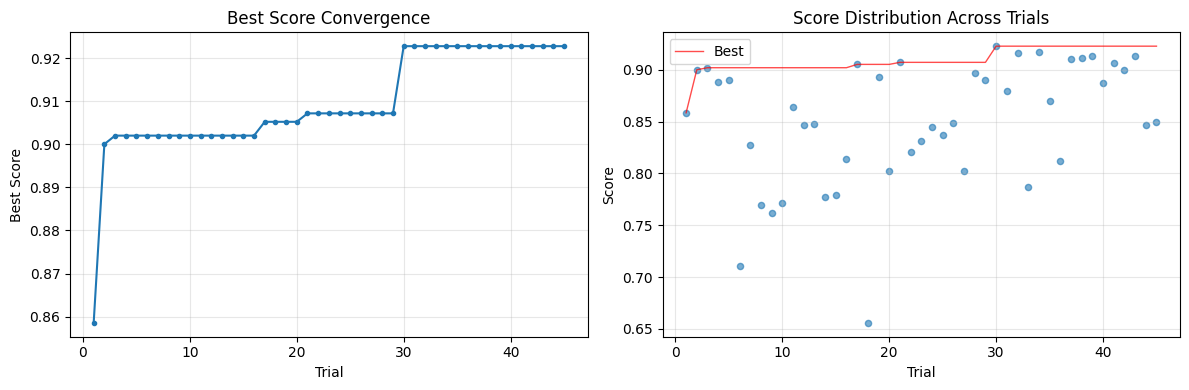

In [ ]:
agent.plot()

In [ ]:
best

{'config': {'n_estimators': 300,
  'learning_rate': 0.22168015262309043,
  'max_depth': 2,
  'min_samples_split': 10,
  'min_samples_leaf': 5,
  'subsample': 0.6922522353395383},
 'metrics': 0.9228518613276018}

In [ ]:
agent.load()

📂 Loaded 45 results from results.json
